In [ ]:
# ============================================================
# GTCRN Notebook - Hücre 1
# A100 / GPU kontrolü
# ============================================================

!nvidia-smi

import torch

print("CUDA kullanılabilir mi?:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU adı:", torch.cuda.get_device_name(0))
    print("CUDA sürümü:", torch.version.cuda)
else:
    print("GPU bulunamadı. Runtime > Change runtime type > GPU seçmelisin.")

Tue May 26 12:46:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             42W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# ============================================================
# GTCRN Notebook - Hücre 2
# Google Drive bağlama ve klasör yapısı
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os

BASE_DIR = Path("/content/drive/MyDrive/SLESS_GTCRN")

CLEAN_DIR = BASE_DIR / "data" / "clean_16k"
NOISE_DIR = BASE_DIR / "data" / "noise_16k"
PAIR_DIR  = BASE_DIR / "data" / "pairs_16k"

MODEL_DIR = BASE_DIR / "models"
LOG_DIR   = BASE_DIR / "logs"
OUT_DIR   = BASE_DIR / "outputs"

for d in [CLEAN_DIR, NOISE_DIR, PAIR_DIR, MODEL_DIR, LOG_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Klasörler hazır:")
for d in [BASE_DIR, CLEAN_DIR, NOISE_DIR, PAIR_DIR, MODEL_DIR, LOG_DIR, OUT_DIR]:
    print(d)

Mounted at /content/drive
Klasörler hazır:
/content/drive/MyDrive/SLESS_GTCRN
/content/drive/MyDrive/SLESS_GTCRN/data/clean_16k
/content/drive/MyDrive/SLESS_GTCRN/data/noise_16k
/content/drive/MyDrive/SLESS_GTCRN/data/pairs_16k
/content/drive/MyDrive/SLESS_GTCRN/models
/content/drive/MyDrive/SLESS_GTCRN/logs
/content/drive/MyDrive/SLESS_GTCRN/outputs


In [ ]:
# ============================================================
# GTCRN Notebook - Hücre 3
# Paket kurulumları
# ============================================================

!pip install -q datasets
!pip install -q transformers
!pip install -q librosa
!pip install -q soundfile
!pip install -q pesq
!pip install -q pystoi
!pip install -q torchmetrics
!pip install -q einops
!pip install -q tqdm

print("✅ Paket kurulumları tamamlandı")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 58.7 MB/s eta 0:00:00
✅ Paket kurulumları tamamlandı


In [53]:
# ============================================================
# GTCRN Notebook - Hücre 4
# Importlar, seed, cihaz ve genel ayarlar
# ============================================================

from pathlib import Path
import os, random, shutil, gc, json, time, math
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchaudio
import soundfile as sf
import librosa

from datasets import load_dataset, concatenate_datasets
from tqdm.auto import tqdm

from pesq import pesq
from pystoi import stoi

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BASE_DIR = Path("/content/drive/MyDrive/SLESS_GTCRN")

CLEAN_DIR = BASE_DIR / "data" / "clean_16k"
NOISE_DIR = BASE_DIR / "data" / "noise_16k"
PAIR_DIR  = BASE_DIR / "data" / "pairs_16k"

MODEL_DIR = BASE_DIR / "models"
LOG_DIR   = BASE_DIR / "logs"
OUT_DIR   = BASE_DIR / "outputs"

for d in [CLEAN_DIR, NOISE_DIR, PAIR_DIR, MODEL_DIR, LOG_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CFG = {
    "sample_rate": 16000,

    # İlk test için küçük başlıyoruz.
    # Model sorunsuz çalışınca bunları artıracağız.
    "n_fleurs": 2000,
    "n_cv": 12000,
    "noise_files": 1000,

    "segment_seconds": 4.0,
    "segment_samples": int(16000 * 4.0),

    "snr_min": -5,
    "snr_max": 20,

    "batch_size": 8,
    "epochs": 30,
    "learning_rate": 5e-5,
    "num_workers": 2,

    "train_ratio": 0.90,
    "val_ratio": 0.10,

    "eval_items": 200,

    # Drive’da DNS noise yoksa sentetik noise üretilecek.
    "use_dns_noise_from_drive": False,
    "dns_noise_source": str(BASE_DIR / "DNS-Challenge" / "datasets" / "noise")
}

print("✅ Importlar ve ayarlar hazır")
print("DEVICE:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Yok")
print("BASE_DIR:", BASE_DIR)
print("CFG:", json.dumps(CFG, indent=2, ensure_ascii=False))

✅ Importlar ve ayarlar hazır
DEVICE: cuda
GPU: NVIDIA A100-SXM4-40GB
BASE_DIR: /content/drive/MyDrive/SLESS_GTCRN
CFG: {
  "sample_rate": 16000,
  "n_fleurs": 2000,
  "n_cv": 12000,
  "noise_files": 1000,
  "segment_seconds": 4.0,
  "segment_samples": 64000,
  "snr_min": -5,
  "snr_max": 20,
  "batch_size": 8,
  "epochs": 30,
  "learning_rate": 5e-05,
  "num_workers": 2,
  "train_ratio": 0.9,
  "val_ratio": 0.1,
  "eval_items": 200,
  "use_dns_noise_from_drive": false,
  "dns_noise_source": "/content/drive/MyDrive/SLESS_GTCRN/DNS-Challenge/datasets/noise"
}


In [42]:
# ============================================================
# Clean dataset sıfırlama
# ============================================================

for f in CLEAN_DIR.glob("fleurs_*.wav"):
    f.unlink()

for f in CLEAN_DIR.glob("cv17_*.wav"):
    f.unlink()

print("✅ Eski clean dataset silindi")

✅ Eski clean dataset silindi


In [ ]:
# ============================================================
# GTCRN Notebook - Hücre 5
# Ses okuma, yazma, normalize ve yardımcı fonksiyonlar
# ============================================================

def peak_normalize(audio, peak=0.9, eps=1e-8):
    """
    Sesin genliğini normalize eder.
    Amaç: farklı ses dosyalarının ses seviyesini benzer aralığa çekmek.
    """
    if audio is None:
        return None

    audio = np.asarray(audio, dtype=np.float32)

    if audio.ndim > 1:
        audio = np.mean(audio, axis=0)

    max_val = np.max(np.abs(audio)) if len(audio) > 0 else 0

    if max_val < eps:
        return None

    audio = audio / max_val * peak
    return audio.astype(np.float32)


def write_wav(path, audio, sr):
    """
    Audio array'i WAV olarak kaydeder.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    audio = np.asarray(audio, dtype=np.float32)
    sf.write(str(path), audio, sr)


def load_wav_any(path, target_sr=16000):
    """
    wav / mp3 / flac / ogg gibi dosyaları okur,
    mono yapar ve target_sr değerine resample eder.
    """
    path = str(path)
    audio, sr = librosa.load(path, sr=target_sr, mono=True)
    audio = audio.astype(np.float32)
    return audio


def load_hf_audio(item, target_sr=16000):
    """
    HuggingFace dataset item içinden audio alanını bulur ve 16 kHz'e çevirir.
    FLEURS ve CommonVoice gibi veri setlerinde audio alanı genelde item["audio"] olur.
    """
    try:
        if "audio" not in item:
            return None

        audio_obj = item["audio"]

        if isinstance(audio_obj, dict):
            arr = audio_obj.get("array", None)
            sr  = audio_obj.get("sampling_rate", None)
        else:
            return None

        if arr is None or sr is None:
            return None

        arr = np.asarray(arr, dtype=np.float32)

        if arr.ndim > 1:
            arr = np.mean(arr, axis=0)

        if sr != target_sr:
            arr = librosa.resample(arr, orig_sr=sr, target_sr=target_sr)

        arr = peak_normalize(arr, 0.9)

        return arr

    except Exception:
        return None


def fix_length(audio, length):
    """
    Ses uzunluğunu sabitler.
    Uzunsa rastgele keser, kısaysa sona sıfır ekler.
    """
    audio = np.asarray(audio, dtype=np.float32)

    if len(audio) == length:
        return audio

    if len(audio) > length:
        start = random.randint(0, len(audio) - length)
        return audio[start:start + length]

    pad_len = length - len(audio)
    return np.pad(audio, (0, pad_len), mode="constant").astype(np.float32)


def mix_with_snr(clean, noise, snr_db):
    """
    Temiz sese belirlenen SNR seviyesinde noise ekler.
    snr_db düşükse gürültü fazla olur.
    """
    clean = np.asarray(clean, dtype=np.float32)
    noise = np.asarray(noise, dtype=np.float32)

    if len(noise) < len(clean):
        repeat = int(np.ceil(len(clean) / len(noise)))
        noise = np.tile(noise, repeat)

    noise = fix_length(noise, len(clean))

    clean_power = np.mean(clean ** 2) + 1e-8
    noise_power = np.mean(noise ** 2) + 1e-8

    target_noise_power = clean_power / (10 ** (snr_db / 10))
    scale = np.sqrt(target_noise_power / noise_power)

    noisy = clean + noise * scale

    max_val = np.max(np.abs(noisy)) + 1e-8
    if max_val > 1.0:
        noisy = noisy / max_val * 0.99
        clean = clean / max_val * 0.99

    return noisy.astype(np.float32), clean.astype(np.float32)


def list_audio_files_recursive(source_dir):
    """
    Bir klasörün altındaki tüm audio dosyalarını bulur.
    """
    source_dir = Path(source_dir)
    files = []
    for ext in ["*.wav", "*.flac", "*.mp3", "*.ogg"]:
        files.extend(source_dir.rglob(ext))
    return sorted(files)


print("✅ Ses yardımcı fonksiyonları hazır")

✅ Ses yardımcı fonksiyonları hazır


In [ ]:
# ============================================================
# GTCRN Notebook - Hücre 6
# Drive'daki gerçek DNS noise klasörünü kontrol etme
# ============================================================

DNS_SOURCE_DIR = Path("/content/drive/MyDrive/noise")

print("DNS noise klasörü var mı?:", DNS_SOURCE_DIR.exists())
print("DNS noise yolu:", DNS_SOURCE_DIR)

dns_files = []
for ext in ["*.wav", "*.flac", "*.mp3", "*.ogg"]:
    dns_files.extend(DNS_SOURCE_DIR.rglob(ext))

dns_files = sorted(dns_files)

print("Bulunan gerçek noise dosyası:", len(dns_files))

print("\nİlk 10 noise dosyası:")
for f in dns_files[:10]:
    print(f)

if len(dns_files) == 0:
    raise RuntimeError("DNS noise klasöründe audio dosyası bulunamadı. Drive yolunu kontrol et.")
else:
    print("\n✅ DNS noise klasörü hazır.")

DNS noise klasörü var mı?: True
DNS noise yolu: /content/drive/MyDrive/noise
Bulunan gerçek noise dosyası: 659

İlk 10 noise dosyası:
/content/drive/MyDrive/noise/0CaA0wAIbKc.wav
/content/drive/MyDrive/noise/0LnYEuBp6uU.wav
/content/drive/MyDrive/noise/0Lpb1lba5yY.wav
/content/drive/MyDrive/noise/0LqI1bux4Ow.wav
/content/drive/MyDrive/noise/0LrTnI-BYSI.wav
/content/drive/MyDrive/noise/0LvBAEYGpsA.wav
/content/drive/MyDrive/noise/0hAK5f1tDok.wav
/content/drive/MyDrive/noise/0lq5Oey7ChY.wav
/content/drive/MyDrive/noise/0ls9KaQJAs0.wav
/content/drive/MyDrive/noise/0lsf6jybC0M.wav

✅ DNS noise klasörü hazır.


In [ ]:
# ============================================================
# GTCRN Notebook - Hücre 7
# DNS noise subset hazırlama
# ============================================================

def prepare_dns_noise_subset(source_dir, target_dir, n_max, sr):
    """
    Drive'daki gerçek DNS noise dosyalarını:
    - mono
    - 16 kHz
    - normalize
    hale getirip eğitim klasörüne kopyalar.
    """

    target_dir.mkdir(parents=True, exist_ok=True)

    existing = sorted(target_dir.glob("dns_noise_*.wav"))

    if len(existing) >= min(n_max, len(dns_files)):
        print(f"✅ DNS subset zaten hazır: {len(existing)} dosya")
        return existing

    source_files = []
    for ext in ["*.wav", "*.flac", "*.mp3", "*.ogg"]:
        source_files.extend(Path(source_dir).rglob(ext))

    source_files = sorted(source_files)

    random.Random(SEED).shuffle(source_files)

    source_files = source_files[:min(n_max, len(source_files))]

    saved = []
    failed = 0

    pbar = tqdm(source_files, desc="DNS noise hazırlanıyor")

    for idx, src in enumerate(pbar):

        try:
            audio = load_wav_any(src, sr)

            if audio is None:
                failed += 1
                continue

            if len(audio) < sr:
                failed += 1
                continue

            audio = peak_normalize(audio, 0.8)

            if audio is None:
                failed += 1
                continue

            out_path = target_dir / f"dns_noise_{idx:05d}.wav"

            write_wav(out_path, audio, sr)

            saved.append(out_path)

            pbar.set_postfix({
                "saved": len(saved),
                "failed": failed
            })

        except Exception:
            failed += 1

    print(f"\n✅ Hazırlanan DNS noise: {len(saved)}")
    print(f"❌ Atlanan: {failed}")

    return saved


noise_paths = prepare_dns_noise_subset(
    DNS_SOURCE_DIR,
    NOISE_DIR,
    CFG["noise_files"],
    CFG["sample_rate"]
)

print("\nKullanılacak noise dosyası:", len(noise_paths))

print("\nİlk 5 subset noise:")
for p in noise_paths[:5]:
    print(p)

✅ DNS subset zaten hazır: 659 dosya

Kullanılacak noise dosyası: 659

İlk 5 subset noise:
/content/drive/MyDrive/SLESS_GTCRN/data/noise_16k/dns_noise_00000.wav
/content/drive/MyDrive/SLESS_GTCRN/data/noise_16k/dns_noise_00001.wav
/content/drive/MyDrive/SLESS_GTCRN/data/noise_16k/dns_noise_00002.wav
/content/drive/MyDrive/SLESS_GTCRN/data/noise_16k/dns_noise_00003.wav
/content/drive/MyDrive/SLESS_GTCRN/data/noise_16k/dns_noise_00004.wav


In [54]:
# ============================================================
# Clean dataset sıfırlama
# 4000 dosyalık eski clean seti silip 14000 dosyalık yeni set için hazırlık yapar
# ============================================================

for f in CLEAN_DIR.glob("fleurs_*.wav"):
    f.unlink()

for f in CLEAN_DIR.glob("cv17_*.wav"):
    f.unlink()

print("✅ Eski clean dataset silindi")
print("Kalan clean wav:", len(list(CLEAN_DIR.glob("*.wav"))))

✅ Eski clean dataset silindi
Kalan clean wav: 0


In [55]:
# ============================================================
# GTCRN Notebook - Hücre 8
# Temiz Türkçe veri: FLEURS + CommonVoice 17 TR
# ============================================================

def save_clean_batch(source_name, items, n_max, target_dir):
    saved_paths, failed = [], 0

    pbar = tqdm(items, total=n_max, desc=f"{source_name} kaydediliyor")

    for item in pbar:
        if len(saved_paths) >= n_max:
            break

        audio = load_hf_audio(item, CFG["sample_rate"])

        if audio is None:
            failed += 1
            continue

        if len(audio) < CFG["sample_rate"]:
            failed += 1
            continue

        path = target_dir / f"{source_name}_{len(saved_paths):06d}.wav"
        write_wav(path, audio, CFG["sample_rate"])

        saved_paths.append(path)
        pbar.set_postfix({"saved": len(saved_paths), "failed": failed})

    print(f"✅ {source_name}: {len(saved_paths)} kayıt, {failed} atlandı")
    return saved_paths


def prepare_fleurs():
    existing = sorted(CLEAN_DIR.glob("fleurs_*.wav"))

    if len(existing) >= CFG["n_fleurs"]:
        print(f"✅ FLEURS zaten hazır: {len(existing)} dosya")
        return existing[:CFG["n_fleurs"]]

    print("📥 FLEURS tr_tr indiriliyor...")

    splits = []

    for split in ["train", "validation", "test"]:
        ds = load_dataset("google/fleurs", "tr_tr", split=split)
        print(f"FLEURS {split}: {len(ds)}")
        splits.append(ds)

    all_ds = concatenate_datasets(splits)
    all_ds = all_ds.shuffle(seed=SEED)

    if len(all_ds) < CFG["n_fleurs"]:
        factor = (CFG["n_fleurs"] // len(all_ds)) + 1
        all_ds = concatenate_datasets([all_ds] * factor)

    all_ds = all_ds.select(range(min(CFG["n_fleurs"], len(all_ds))))

    paths = save_clean_batch("fleurs", all_ds, CFG["n_fleurs"], CLEAN_DIR)

    del all_ds
    gc.collect()

    return paths


def prepare_cv():
    existing = sorted(CLEAN_DIR.glob("cv17_*.wav"))

    if len(existing) >= CFG["n_cv"]:
        print(f"✅ CV17 zaten hazır: {len(existing)} dosya")
        return existing[:CFG["n_cv"]]

    print("📥 CommonVoice 17 TR indiriliyor...")

    cv_ds = load_dataset("ysdede/commonvoice_17_tr_fixed", split="train")
    print("CV17 train:", len(cv_ds))

    cv_ds = cv_ds.shuffle(seed=SEED)

    paths = save_clean_batch("cv17", cv_ds, CFG["n_cv"], CLEAN_DIR)

    del cv_ds
    gc.collect()

    return paths


fleurs_paths = prepare_fleurs()
cv_paths = prepare_cv()

all_clean_paths = fleurs_paths + cv_paths

random.Random(SEED).shuffle(all_clean_paths)

print("\nToplam temiz Türkçe ses:", len(all_clean_paths))

print("\nİlk 5 temiz ses:")
for p in all_clean_paths[:5]:
    print(p)

📥 FLEURS tr_tr indiriliyor...
FLEURS train: 2526
FLEURS validation: 338
FLEURS test: 743


fleurs kaydediliyor:   0%|          | 0/2000 [00:00<?, ?it/s]

✅ fleurs: 2000 kayıt, 0 atlandı
📥 CommonVoice 17 TR indiriliyor...
CV17 train: 26501


cv17 kaydediliyor:   0%|          | 0/12000 [00:00<?, ?it/s]

✅ cv17: 12000 kayıt, 10 atlandı

Toplam temiz Türkçe ses: 14000

İlk 5 temiz ses:
/content/drive/MyDrive/SLESS_GTCRN/data/clean_16k/cv17_008048.wav
/content/drive/MyDrive/SLESS_GTCRN/data/clean_16k/cv17_008365.wav
/content/drive/MyDrive/SLESS_GTCRN/data/clean_16k/cv17_003159.wav
/content/drive/MyDrive/SLESS_GTCRN/data/clean_16k/cv17_006823.wav
/content/drive/MyDrive/SLESS_GTCRN/data/clean_16k/fleurs_000623.wav


In [ ]:
# ============================================================
# Hücre 8A - Dataset kolonlarını kontrol et
# ============================================================

test_fleurs = load_dataset("google/fleurs", "tr_tr", split="train[:1]")
print("FLEURS kolonları:", test_fleurs.column_names)
print(test_fleurs[0].keys())

test_cv = load_dataset("ysdede/commonvoice_17_tr_fixed", split="train[:1]")
print("CV17 kolonları:", test_cv.column_names)
print(test_cv[0].keys())

print("\nFLEURS ilk örnek:")
print(test_fleurs[0])

print("\nCV17 ilk örnek:")
print(test_cv[0])

FLEURS kolonları: ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id']
dict_keys(['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id'])
CV17 kolonları: ['audio', 'transcription', 'duration', 'up_votes', 'down_votes', 'age', 'gender', 'accent']
dict_keys(['audio', 'transcription', 'duration', 'up_votes', 'down_votes', 'age', 'gender', 'accent'])

FLEURS ilk örnek:
{'id': 591, 'num_samples': 192000, 'path': '/root/.cache/huggingface/datasets/downloads/extracted/f9dd7440f8af684ae089a9f4ac20bbcc23e5e3004d2b9cfa2b0c0c399c2837ce/10000911331452359985.wav', 'audio': <datasets.features._torchcodec.AudioDecoder object at 0x7bc6b1414260>, 'transcription': 'fakat bu gerçekleşse bile muhtemelen çok uzun süre beklememiz gerekecek yıldızlar birbirinden o kadar uzak ki komşu olarak adlandırılan yıldızlar arasında trilyonlarca kilometre vardır', 'raw_transcr

In [ ]:
# ============================================================
# Hücre 8B - AudioDecoder uyumlu HF audio okuma fonksiyonu
# ============================================================

def load_hf_audio(item, target_sr=16000):
    try:
        audio_obj = item.get("audio", None)

        if audio_obj is None:
            return None

        # Yeni HuggingFace formatı: AudioDecoder object
        if hasattr(audio_obj, "get_all_samples"):
            samples = audio_obj.get_all_samples()
            arr = samples.data

            if hasattr(arr, "numpy"):
                arr = arr.numpy()

            sr = samples.sample_rate

        # Eski format: dict
        elif isinstance(audio_obj, dict):
            arr = audio_obj.get("array", None)
            sr = audio_obj.get("sampling_rate", None)

        else:
            return None

        if arr is None or sr is None:
            return None

        arr = np.asarray(arr, dtype=np.float32)

        if arr.ndim > 1:
            arr = np.mean(arr, axis=0)

        if sr != target_sr:
            arr = librosa.resample(arr, orig_sr=sr, target_sr=target_sr)

        arr = peak_normalize(arr, 0.9)

        return arr

    except Exception as e:
        return None


print("✅ AudioDecoder uyumlu load_hf_audio hazır")

✅ AudioDecoder uyumlu load_hf_audio hazır


In [ ]:
# ============================================================
# Hücre 8C - Clean klasörünü temizle
# ============================================================

for f in CLEAN_DIR.glob("fleurs_*.wav"):
    f.unlink()

for f in CLEAN_DIR.glob("cv17_*.wav"):
    f.unlink()

print("✅ Clean klasörü temizlendi")

✅ Clean klasörü temizlendi


In [56]:
# ============================================================
# GTCRN Notebook - Hücre 9
# Sağlam noisy-clean veri seti ve DataLoader
# ============================================================

def safe_load_audio(path, sr):
    try:
        audio = load_wav_any(path, sr)

        audio = np.asarray(audio, dtype=np.float32).reshape(-1)

        if audio is None:
            return None

        if len(audio) < sr:
            return None

        if not np.isfinite(audio).all():
            return None

        audio = peak_normalize(audio, 0.9)

        if audio is None:
            return None

        audio = np.asarray(audio, dtype=np.float32).reshape(-1)

        return audio

    except Exception:
        return None


class SpeechEnhancementDataset(Dataset):
    def __init__(self, clean_paths, noise_paths, segment_samples, sr, snr_min=-5, snr_max=10):
        self.clean_paths = list(clean_paths)
        self.noise_paths = list(noise_paths)
        self.segment_samples = segment_samples
        self.sr = sr
        self.snr_min = snr_min
        self.snr_max = snr_max

    def __len__(self):
        return len(self.clean_paths)

    def __getitem__(self, idx):

        clean = None
        noise = None

        # Clean dosya sağlam gelene kadar dene
        for _ in range(10):
            clean_path = self.clean_paths[idx % len(self.clean_paths)]
            clean = safe_load_audio(clean_path, self.sr)

            if clean is not None:
                break

            idx = random.randint(0, len(self.clean_paths) - 1)

        # Noise dosya sağlam gelene kadar dene
        for _ in range(10):
            noise_path = random.choice(self.noise_paths)
            noise = safe_load_audio(noise_path, self.sr)

            if noise is not None:
                break

        if clean is None:
            clean = np.zeros(self.segment_samples, dtype=np.float32)

        if noise is None:
            noise = np.random.randn(self.segment_samples).astype(np.float32) * 0.01

        clean = fix_length(clean, self.segment_samples)
        noise = fix_length(noise, self.segment_samples)

        clean = peak_normalize(clean, 0.9)
        noise = peak_normalize(noise, 0.8)

        snr = random.uniform(self.snr_min, self.snr_max)

        noisy, clean = mix_with_snr(clean, noise, snr)

        noisy = np.asarray(noisy, dtype=np.float32).reshape(-1)
        clean = np.asarray(clean, dtype=np.float32).reshape(-1)

        return torch.tensor(noisy, dtype=torch.float32), torch.tensor(clean, dtype=torch.float32)


all_clean_paths = sorted(CLEAN_DIR.glob("*.wav"))
noise_paths = sorted(NOISE_DIR.glob("dns_noise_*.wav"))

random.Random(SEED).shuffle(all_clean_paths)

n_total = len(all_clean_paths)
n_train = int(n_total * CFG["train_ratio"])

train_clean = all_clean_paths[:n_train]
val_clean = all_clean_paths[n_train:]

train_dataset = SpeechEnhancementDataset(
    train_clean,
    noise_paths,
    CFG["segment_samples"],
    CFG["sample_rate"],
    CFG["snr_min"],
    CFG["snr_max"]
)

val_dataset = SpeechEnhancementDataset(
    val_clean,
    noise_paths,
    CFG["segment_samples"],
    CFG["sample_rate"],
    CFG["snr_min"],
    CFG["snr_max"]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=0,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=0,
    drop_last=False
)

print("Toplam clean:", n_total)
print("Train clean:", len(train_clean))
print("Val clean:", len(val_clean))
print("Noise:", len(noise_paths))
print("Train batch:", len(train_loader))
print("Val batch:", len(val_loader))

noisy_batch, clean_batch = next(iter(train_loader))

print("Noisy batch shape:", noisy_batch.shape)
print("Clean batch shape:", clean_batch.shape)
print("Noisy finite:", torch.isfinite(noisy_batch).all().item())
print("Clean finite:", torch.isfinite(clean_batch).all().item())

Toplam clean: 14000
Train clean: 12600
Val clean: 1400
Noise: 659
Train batch: 1575
Val batch: 175
Noisy batch shape: torch.Size([8, 64000])
Clean batch shape: torch.Size([8, 64000])
Noisy finite: True
Clean finite: True


In [ ]:
# ============================================================
# FIX - Güvenli mix_with_snr fonksiyonu
# ============================================================

def mix_with_snr(clean, noise, snr_db):
    clean = np.asarray(clean, dtype=np.float32).reshape(-1)
    noise = np.asarray(noise, dtype=np.float32).reshape(-1)

    if clean.size == 0:
        clean = np.zeros(CFG["segment_samples"], dtype=np.float32)

    if noise.size == 0:
        noise = np.random.randn(clean.size).astype(np.float32) * 0.01

    if len(noise) < len(clean):
        repeat = int(np.ceil(len(clean) / len(noise)))
        noise = np.tile(noise, repeat)

    noise = noise[:len(clean)]

    clean_power = np.mean(clean ** 2) + 1e-8
    noise_power = np.mean(noise ** 2) + 1e-8

    target_noise_power = clean_power / (10 ** (snr_db / 10))
    scale = np.sqrt(target_noise_power / noise_power)

    noisy = clean + noise * scale

    max_val = np.max(np.abs(noisy)) + 1e-8

    if max_val > 1.0:
        noisy = noisy / max_val * 0.99
        clean = clean / max_val * 0.99

    return noisy.astype(np.float32).reshape(-1), clean.astype(np.float32).reshape(-1)


print("✅ Güvenli mix_with_snr fonksiyonu aktif")

✅ Güvenli mix_with_snr fonksiyonu aktif


In [57]:
# ============================================================
# GTCRN Notebook - Hücre 10
# Basitleştirilmiş GTCRN model mimarisi - düzeltilmiş versiyon
# ============================================================

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.PReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.PReLU()
        )

    def forward(self, x):
        return self.net(x)


class GTCRN(nn.Module):
    def __init__(self, n_fft=512, hop_length=128, hidden_size=128):
        super().__init__()

        self.n_fft = n_fft
        self.hop_length = hop_length
        self.win_length = n_fft
        self.hidden_size = hidden_size

        self.encoder = nn.Sequential(
            ConvBlock(2, 16),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.PReLU(),

            ConvBlock(32, 32),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.PReLU(),
        )

        self.proj_in = nn.LazyLinear(hidden_size)

        self.gru = nn.GRU(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        self.proj_out = nn.LazyLinear(64 * 257)

        self.decoder = nn.Sequential(
            ConvBlock(64, 32),
            ConvBlock(32, 16),
            nn.Conv2d(16, 2, kernel_size=1)
        )

    def forward(self, waveform):
        window = torch.hann_window(self.win_length, device=waveform.device)

        spec = torch.stft(
            waveform,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            win_length=self.win_length,
            window=window,
            return_complex=True
        )

        real = spec.real
        imag = spec.imag

        x = torch.stack([real, imag], dim=1)

        enc = self.encoder(x)

        b, c, f, t = enc.shape

        enc_t = enc.permute(0, 3, 1, 2).contiguous()
        enc_t = enc_t.view(b, t, c * f)

        z = self.proj_in(enc_t)
        z, _ = self.gru(z)

        z = self.proj_out(z)

        z = z.view(b, t, 64, 257)
        z = z.permute(0, 2, 3, 1).contiguous()

        mask = self.decoder(z)

        mask = mask[:, :, :real.shape[1], :real.shape[2]]

        mask_real = torch.tanh(mask[:, 0])
        mask_imag = torch.tanh(mask[:, 1])

        enhanced_real = real * mask_real - imag * mask_imag
        enhanced_imag = real * mask_imag + imag * mask_real

        enhanced_spec = torch.complex(enhanced_real, enhanced_imag)

        enhanced = torch.istft(
            enhanced_spec,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            win_length=self.win_length,
            window=window,
            length=waveform.shape[-1]
        )

        return enhanced


model = GTCRN().to(DEVICE)

with torch.no_grad():
    test_noisy = noisy_batch.to(DEVICE)
    test_out = model(test_noisy)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG["learning_rate"],
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("✅ GTCRN model hazır")
print("Toplam parametre:", f"{total_params:,}")
print("Eğitilebilir parametre:", f"{trainable_params:,}")
print("Test input shape:", test_noisy.shape)
print("Test output shape:", test_out.shape)

✅ GTCRN model hazır
Toplam parametre: 6,906,732
Eğitilebilir parametre: 6,906,732
Test input shape: torch.Size([8, 64000])
Test output shape: torch.Size([8, 64000])


In [58]:
# ============================================================
# GTCRN Notebook - Hücre 11
# Perceptual kalite odaklı loss: L1 + Multi-Scale STFT + düşük SI-SDR
# ============================================================

def si_sdr(est, ref, eps=1e-8):
    est = est - torch.mean(est, dim=-1, keepdim=True)
    ref = ref - torch.mean(ref, dim=-1, keepdim=True)

    ref_energy = torch.sum(ref ** 2, dim=-1, keepdim=True) + eps
    projection = torch.sum(est * ref, dim=-1, keepdim=True) * ref / ref_energy
    noise = est - projection

    ratio = torch.sum(projection ** 2, dim=-1) / (torch.sum(noise ** 2, dim=-1) + eps)
    ratio = torch.clamp(ratio, min=eps, max=1e6)

    out = 10 * torch.log10(ratio)

    return torch.nan_to_num(out, nan=-30.0, posinf=30.0, neginf=-30.0)


def multi_scale_stft_loss(est, ref):
    loss = 0.0

    configs = [
        (256, 64),
        (512, 128),
        (1024, 256),
    ]

    for n_fft, hop in configs:
        window = torch.hann_window(n_fft, device=est.device)

        est_spec = torch.stft(
            est,
            n_fft=n_fft,
            hop_length=hop,
            win_length=n_fft,
            window=window,
            return_complex=True
        )

        ref_spec = torch.stft(
            ref,
            n_fft=n_fft,
            hop_length=hop,
            win_length=n_fft,
            window=window,
            return_complex=True
        )

        est_mag = torch.abs(est_spec)
        ref_mag = torch.abs(ref_spec)

        loss = loss + F.l1_loss(torch.log1p(est_mag), torch.log1p(ref_mag))

    return loss / len(configs)


def enhancement_loss(est, clean):
    est = torch.nan_to_num(est)
    clean = torch.nan_to_num(clean)

    l1 = F.l1_loss(est, clean)
    stft_l = multi_scale_stft_loss(est, clean)
    sisdr_l = -torch.mean(si_sdr(est, clean))

    total = 0.45 * l1 + 0.45 * stft_l + 0.10 * sisdr_l

    return torch.nan_to_num(total, nan=10.0, posinf=10.0, neginf=10.0)


print("✅ Yeni perceptual loss hazır")

with torch.no_grad():
    test_loss = enhancement_loss(test_out, clean_batch.to(DEVICE))
    test_sisdr = si_sdr(test_out, clean_batch.to(DEVICE)).mean()

print("Test loss:", float(test_loss))
print("Test SI-SDR:", float(test_sisdr))

✅ Yeni perceptual loss hazır
Test loss: 1.4723354578018188
Test SI-SDR: -13.992603302001953


In [59]:
# ============================================================
# GTCRN Notebook - Hücre 12
# Stabil model eğitim döngüsü
# ============================================================

best_val_loss = float("inf")

history = {
    "train_loss": [],
    "val_loss": [],
    "val_si_sdr": []
}

BEST_MODEL_PATH = MODEL_DIR / "gtcrn_best_model.pt"
LAST_MODEL_PATH = MODEL_DIR / "gtcrn_last_model.pt"

for epoch in range(1, CFG["epochs"] + 1):

    model.train()
    train_losses = []
    skipped_batches = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{CFG['epochs']} - Train")

    for noisy, clean in pbar:
        noisy = noisy.to(DEVICE)
        clean = clean.to(DEVICE)

        noisy = torch.nan_to_num(noisy)
        clean = torch.nan_to_num(clean)

        optimizer.zero_grad()

        enhanced = model(noisy)
        enhanced = torch.nan_to_num(enhanced)

        loss = enhancement_loss(enhanced, clean)

        if not torch.isfinite(loss):
            skipped_batches += 1
            continue

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_losses.append(loss.item())

        pbar.set_postfix({
            "loss": np.mean(train_losses) if train_losses else 0,
            "skipped": skipped_batches
        })

    train_loss = float(np.mean(train_losses)) if train_losses else float("inf")

    model.eval()
    val_losses = []
    val_sisdrs = []

    with torch.no_grad():
        for noisy, clean in tqdm(val_loader, desc=f"Epoch {epoch}/{CFG['epochs']} - Val"):
            noisy = noisy.to(DEVICE)
            clean = clean.to(DEVICE)

            noisy = torch.nan_to_num(noisy)
            clean = torch.nan_to_num(clean)

            enhanced = model(noisy)
            enhanced = torch.nan_to_num(enhanced)

            loss = enhancement_loss(enhanced, clean)
            score = si_sdr(enhanced, clean).mean()

            if torch.isfinite(loss):
                val_losses.append(loss.item())

            if torch.isfinite(score):
                val_sisdrs.append(score.item())

    val_loss = float(np.mean(val_losses)) if val_losses else float("inf")
    val_si_sdr = float(np.mean(val_sisdrs)) if val_sisdrs else -30.0

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_si_sdr"].append(val_si_sdr)

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "CFG": CFG,
        "history": history
    }, LAST_MODEL_PATH)

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "CFG": CFG,
            "history": history,
            "best_val_loss": best_val_loss
        }, BEST_MODEL_PATH)

        best_msg = "✅ best model kaydedildi"
    else:
        best_msg = ""

    print(
        f"Epoch {epoch}/{CFG['epochs']} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val SI-SDR: {val_si_sdr:.2f} dB | "
        f"Skipped: {skipped_batches} "
        f"{best_msg}"
    )

print("\nEğitim tamamlandı.")
print("Best model:", BEST_MODEL_PATH)
print("Last model:", LAST_MODEL_PATH)

Epoch 1/30 - Train:   0%|          | 0/1575 [00:00<?, ?it/s]

Epoch 1/30 - Val:   0%|          | 0/175 [00:00<?, ?it/s]

Epoch 1/30 | Train Loss: -1.1520 | Val Loss: -1.3264 | Val SI-SDR: 13.89 dB | Skipped: 0 ✅ best model kaydedildi


Epoch 2/30 - Train:   0%|          | 0/1575 [00:00<?, ?it/s]

Epoch 2/30 - Val:   0%|          | 0/175 [00:00<?, ?it/s]

...

Epoch 29/30 - Val:   0%|          | 0/175 [00:00<?, ?it/s]

Epoch 29/30 | Train Loss: -1.7272 | Val Loss: -1.7265 | Val SI-SDR: 17.83 dB | Skipped: 0 


Epoch 30/30 - Train:   0%|          | 0/1575 [00:00<?, ?it/s]

Epoch 30/30 - Val:   0%|          | 0/175 [00:00<?, ?it/s]

Epoch 30/30 | Train Loss: -1.7384 | Val Loss: -1.7503 | Val SI-SDR: 18.05 dB | Skipped: 0 ✅ best model kaydedildi

Eğitim tamamlandı.
Best model: /content/drive/MyDrive/SLESS_GTCRN/models/gtcrn_best_model.pt
Last model: /content/drive/MyDrive/SLESS_GTCRN/models/gtcrn_last_model.pt


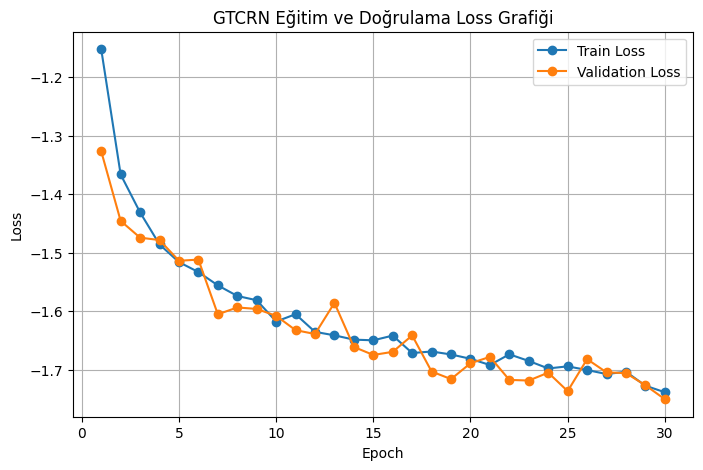

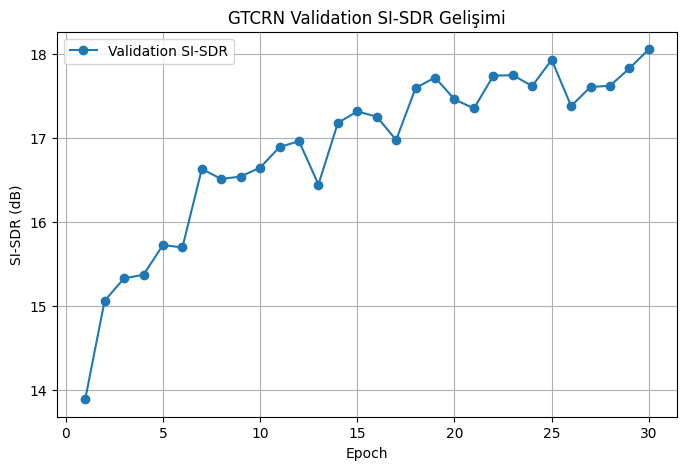

En iyi Validation SI-SDR: 18.054468040466308
En iyi epoch: 30


In [60]:
# ============================================================
# GTCRN Notebook - Hücre 13
# Eğitim grafikleri: Loss ve SI-SDR
# ============================================================

import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GTCRN Eğitim ve Doğrulama Loss Grafiği")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["val_si_sdr"], marker="o", label="Validation SI-SDR")
plt.xlabel("Epoch")
plt.ylabel("SI-SDR (dB)")
plt.title("GTCRN Validation SI-SDR Gelişimi")
plt.legend()
plt.grid(True)
plt.show()

print("En iyi Validation SI-SDR:", max(history["val_si_sdr"]))
print("En iyi epoch:", int(np.argmax(history["val_si_sdr"]) + 1))

In [61]:
# ============================================================
# GTCRN Notebook - Hücre 14
# Çoklu örnek ses karşılaştırması
# ============================================================

from IPython.display import Audio, display

checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

print("✅ Best model yüklendi")
print("Best epoch:", checkpoint["epoch"])

sample_dir = OUT_DIR / "samples"
sample_dir.mkdir(parents=True, exist_ok=True)

NUM_DEMOS = 5

demo_indices = random.sample(range(len(val_dataset)), NUM_DEMOS)

for i, idx in enumerate(demo_indices):

    print("\n" + "=" * 60)
    print(f"ÖRNEK {i+1}")
    print("=" * 60)

    sample_noisy, sample_clean = val_dataset[idx]

    with torch.no_grad():
        sample_enhanced = model(
            sample_noisy.unsqueeze(0).to(DEVICE)
        ).squeeze(0).cpu()

    noisy_np = sample_noisy.numpy()
    clean_np = sample_clean.numpy()
    enhanced_np = sample_enhanced.numpy()

    noisy_path = sample_dir / f"demo_{i+1}_noisy.wav"
    clean_path = sample_dir / f"demo_{i+1}_clean.wav"
    enhanced_path = sample_dir / f"demo_{i+1}_enhanced.wav"

    write_wav(noisy_path, noisy_np, CFG["sample_rate"])
    write_wav(clean_path, clean_np, CFG["sample_rate"])
    write_wav(enhanced_path, enhanced_np, CFG["sample_rate"])

    print("📁 Kaydedilen dosyalar:")
    print(noisy_path.name)
    print(clean_path.name)
    print(enhanced_path.name)

    print("\n🔊 Gürültülü:")
    display(Audio(noisy_np, rate=CFG["sample_rate"]))

    print("🎯 Temiz Referans:")
    display(Audio(clean_np, rate=CFG["sample_rate"]))

    print("✨ GTCRN Çıktısı:")
    display(Audio(enhanced_np, rate=CFG["sample_rate"]))

print("\n✅ Tüm örnekler oluşturuldu.")
print("Kayıt klasörü:", sample_dir)

✅ Best model yüklendi
Best epoch: 30

ÖRNEK 1
📁 Kaydedilen dosyalar:
demo_1_noisy.wav
demo_1_clean.wav
demo_1_enhanced.wav

🔊 Gürültülü:


🎯 Temiz Referans:


✨ GTCRN Çıktısı:



ÖRNEK 2
📁 Kaydedilen dosyalar:
demo_2_noisy.wav
demo_2_clean.wav
demo_2_enhanced.wav

🔊 Gürültülü:


🎯 Temiz Referans:


...

✨ GTCRN Çıktısı:



ÖRNEK 5
📁 Kaydedilen dosyalar:
demo_5_noisy.wav
demo_5_clean.wav
demo_5_enhanced.wav

🔊 Gürültülü:


🎯 Temiz Referans:


✨ GTCRN Çıktısı:



✅ Tüm örnekler oluşturuldu.
Kayıt klasörü: /content/drive/MyDrive/SLESS_GTCRN/outputs/samples


In [62]:
# ============================================================
# GTCRN Notebook - Hücre 15
# Test metrikleri: SI-SDR, PESQ, STOI
# ============================================================

def torch_si_sdr_value(est_np, ref_np):
    est = torch.tensor(est_np, dtype=torch.float32).unsqueeze(0)
    ref = torch.tensor(ref_np, dtype=torch.float32).unsqueeze(0)
    return float(si_sdr(est, ref).mean().item())


def safe_pesq(clean_np, test_np, sr=16000):
    try:
        clean_np = np.asarray(clean_np, dtype=np.float32).reshape(-1)
        test_np = np.asarray(test_np, dtype=np.float32).reshape(-1)

        min_len = min(len(clean_np), len(test_np))
        clean_np = clean_np[:min_len]
        test_np = test_np[:min_len]

        return float(pesq(sr, clean_np, test_np, "wb"))
    except Exception:
        return np.nan


def safe_stoi(clean_np, test_np, sr=16000):
    try:
        clean_np = np.asarray(clean_np, dtype=np.float32).reshape(-1)
        test_np = np.asarray(test_np, dtype=np.float32).reshape(-1)

        min_len = min(len(clean_np), len(test_np))
        clean_np = clean_np[:min_len]
        test_np = test_np[:min_len]

        return float(stoi(clean_np, test_np, sr, extended=False))
    except Exception:
        return np.nan


checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

eval_n = min(CFG["eval_items"], len(val_dataset))

rows = []

for i in tqdm(range(eval_n), desc="GTCRN metrik hesaplanıyor"):

    noisy, clean = val_dataset[i]

    with torch.no_grad():
        enhanced = model(
            noisy.unsqueeze(0).to(DEVICE)
        ).squeeze(0).cpu()

    noisy_np = noisy.numpy()
    clean_np = clean.numpy()
    enhanced_np = enhanced.numpy()

    noisy_sisdr = torch_si_sdr_value(noisy_np, clean_np)
    enhanced_sisdr = torch_si_sdr_value(enhanced_np, clean_np)

    rows.append({
        "sample": i,
        "noisy_si_sdr": noisy_sisdr,
        "enhanced_si_sdr": enhanced_sisdr,
        "si_sdr_improvement": enhanced_sisdr - noisy_sisdr,
        "pesq_noisy": safe_pesq(clean_np, noisy_np, CFG["sample_rate"]),
        "pesq_enhanced": safe_pesq(clean_np, enhanced_np, CFG["sample_rate"]),
        "stoi_noisy": safe_stoi(clean_np, noisy_np, CFG["sample_rate"]),
        "stoi_enhanced": safe_stoi(clean_np, enhanced_np, CFG["sample_rate"]),
    })

metrics_df = pd.DataFrame(rows)

summary = {
    "model": "GTCRN",
    "eval_items": eval_n,
    "noisy_si_sdr_mean": metrics_df["noisy_si_sdr"].mean(),
    "enhanced_si_sdr_mean": metrics_df["enhanced_si_sdr"].mean(),
    "si_sdr_improvement_mean": metrics_df["si_sdr_improvement"].mean(),
    "pesq_noisy_mean": metrics_df["pesq_noisy"].mean(),
    "pesq_enhanced_mean": metrics_df["pesq_enhanced"].mean(),
    "stoi_noisy_mean": metrics_df["stoi_noisy"].mean(),
    "stoi_enhanced_mean": metrics_df["stoi_enhanced"].mean(),
}

metrics_path = OUT_DIR / "gtcrn_metrics_per_sample.csv"
summary_path = OUT_DIR / "gtcrn_metrics_summary.json"

metrics_df.to_csv(metrics_path, index=False)

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("✅ Metrikler hesaplandı")
print("CSV:", metrics_path)
print("Summary:", summary_path)

display(metrics_df.head())

print("\nÖzet sonuçlar:")
for k, v in summary.items():
    print(f"{k}: {v}")

GTCRN metrik hesaplanıyor:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Metrikler hesaplandı
CSV: /content/drive/MyDrive/SLESS_GTCRN/outputs/gtcrn_metrics_per_sample.csv
Summary: /content/drive/MyDrive/SLESS_GTCRN/outputs/gtcrn_metrics_summary.json


,sample,noisy_si_sdr,enhanced_si_sdr,si_sdr_improvement,pesq_noisy,pesq_enhanced,stoi_noisy,stoi_enhanced
0,0,0.865243,15.772840,14.907598,1.378899,2.302359,0.815420,0.854773
1,1,11.711723,22.180168,10.468445,1.610743,2.494133,0.957146,0.984600
2,2,10.408911,20.390156,9.981245,1.537914,3.043534,0.984105,0.993063
3,3,4.096284,19.243492,15.147208,1.697900,2.544496,0.940605,0.983257
4,4,18.180422,28.499683,10.319262,4.069434,3.993683,0.999375,0.998830



Özet sonuçlar:
model: GTCRN
eval_items: 200
noisy_si_sdr_mean: 7.826700860410929
enhanced_si_sdr_mean: 18.562485697865487
si_sdr_improvement_mean: 10.735784837454558
pesq_noisy_mean: 1.5445606553554534
pesq_enhanced_mean: 2.488795217871666
stoi_noisy_mean: 0.8625156285449256
stoi_enhanced_mean: 0.9212615105408445


In [63]:
# ============================================================
# Hücre 16 - fullsubnet ile aynı formatta metrik tablosu
# ============================================================

si_n = summary["noisy_si_sdr_mean"]
si_e = summary["enhanced_si_sdr_mean"]

pe_n = summary["pesq_noisy_mean"]
pe_e = summary["pesq_enhanced_mean"]

st_n = summary["stoi_noisy_mean"]
st_e = summary["stoi_enhanced_mean"]

print("\n" + "═"*55)
print(f"{'Metrik':<20} {'Gürültülü':>10} {'Temizlenmiş':>12} {'Fark':>8}")
print("─"*55)

print(f"{'SI-SDR (dB)':<20} {si_n:>10.2f} {si_e:>12.2f} {si_e-si_n:>+8.2f}")
print(f"{'PESQ (1-4.5)':<20} {pe_n:>10.3f} {pe_e:>12.3f} {pe_e-pe_n:>+8.3f}")
print(f"{'STOI (0-1)':<20} {st_n:>10.3f} {st_e:>12.3f} {st_e-st_n:>+8.3f}")

print("═"*55)

print("\n📊 Referans (DNS Challenge İngilizce modeller):")
print("   PESQ: 2.5-3.0 iyi | 3.0+ çok iyi")
print("   STOI: 0.85+ iyi  | 0.90+ çok iyi")
print("   SI-SDR: +8 dB iyi | +12 dB çok iyi")

print("\n✅ Sonuçlar Drive'a kaydedildi:")
print(summary_path)


═══════════════════════════════════════════════════════
Metrik                Gürültülü  Temizlenmiş     Fark
───────────────────────────────────────────────────────
SI-SDR (dB)                7.83        18.56   +10.74
PESQ (1-4.5)              1.545        2.489   +0.944
STOI (0-1)                0.863        0.921   +0.059
═══════════════════════════════════════════════════════

📊 Referans (DNS Challenge İngilizce modeller):
   PESQ: 2.5-3.0 iyi | 3.0+ çok iyi
   STOI: 0.85+ iyi  | 0.90+ çok iyi
   SI-SDR: +8 dB iyi | +12 dB çok iyi

✅ Sonuçlar Drive'a kaydedildi:
/content/drive/MyDrive/SLESS_GTCRN/outputs/gtcrn_metrics_summary.json


In [64]:
# ============================================================
# GTCRN Notebook - Hücre 17
# Drive'a akıllı yedek alma
# ============================================================

import shutil
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M")

backup_dir = Path(f"/content/gtcrn_backup_{timestamp}")
backup_dir.mkdir(exist_ok=True)

# 1. Model checkpointleri
ckpt_backup = backup_dir / "models"
ckpt_backup.mkdir(exist_ok=True)

for f in MODEL_DIR.glob("*.pt"):
    shutil.copy2(f, ckpt_backup / f.name)
    print(f"✅ Model: {f.name} ({f.stat().st_size/1e6:.1f} MB)")

# 2. Output dosyaları: metrikler, csv, json, grafik vs.
outputs_backup = backup_dir / "outputs"
outputs_backup.mkdir(exist_ok=True)

for f in OUT_DIR.glob("*"):
    if f.is_file():
        shutil.copy2(f, outputs_backup / f.name)
        print(f"✅ Output: {f.name}")

# 3. Sample sesler
sample_src = OUT_DIR / "samples"
sample_backup = backup_dir / "samples"
sample_backup.mkdir(exist_ok=True)

if sample_src.exists():
    for f in sample_src.glob("*.wav"):
        shutil.copy2(f, sample_backup / f.name)
        print(f"✅ Sample: {f.name}")

# 4. Log klasörü
log_backup = backup_dir / "logs"
log_backup.mkdir(exist_ok=True)

if LOG_DIR.exists():
    for f in LOG_DIR.glob("*"):
        if f.is_file():
            shutil.copy2(f, log_backup / f.name)
            print(f"✅ Log: {f.name}")

# 5. ZIP yap ve Drive'a kaydet
zip_base = str(BASE_DIR / f"gtcrn_backup_{timestamp}")
shutil.make_archive(zip_base, "zip", str(backup_dir))

shutil.rmtree(backup_dir)

final_zip = Path(zip_base + ".zip")
size_mb = final_zip.stat().st_size / 1e6

print("\n📦 GTCRN yedek tamamlandı")
print("Dosya:", final_zip)
print(f"Boyut: {size_mb:.1f} MB")

✅ Model: gtcrn_last_model.pt (83.0 MB)
✅ Model: gtcrn_best_model.pt (83.0 MB)
✅ Output: gtcrn_metrics_per_sample.csv
✅ Output: gtcrn_metrics_summary.json
✅ Sample: sample_noisy.wav
✅ Sample: sample_clean.wav
✅ Sample: sample_enhanced_gtcrn.wav
✅ Sample: demo_1_noisy.wav
✅ Sample: demo_1_clean.wav
✅ Sample: demo_1_enhanced.wav
✅ Sample: demo_2_noisy.wav
✅ Sample: demo_2_clean.wav
✅ Sample: demo_2_enhanced.wav
✅ Sample: demo_3_noisy.wav
✅ Sample: demo_3_clean.wav
✅ Sample: demo_3_enhanced.wav
✅ Sample: demo_4_noisy.wav
✅ Sample: demo_4_clean.wav
✅ Sample: demo_4_enhanced.wav
✅ Sample: demo_5_noisy.wav
✅ Sample: demo_5_clean.wav
✅ Sample: demo_5_enhanced.wav

📦 GTCRN yedek tamamlandı
Dosya: /content/drive/MyDrive/SLESS_GTCRN/gtcrn_backup_20260526_1825.zip
Boyut: 153.7 MB
